### Campaign Finance and Congressional Election Outcomes — Part 2: Classification Modeling

**Goal:** We train, tune, and compare four binary classification models to predict whether a congressional candidate wins or loses their election based on campaign finance variables. We use cross-validation, GridSearchCV/RandomizedSearchCV for hyperparameter tuning, and evaluate models on accuracy and ROC-AUC score.

**Models trained:**
- Logistic Regression (baseline)
- Decision Tree
- Random Forest
- Gradient Boosting

The best model will be further analyzed in Part 3 (Evaluation).

#### Import and Setup

In [9]:
# standard library, modeling, and evaluation imports
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold)
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             recall_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline

#### Load Clean Dataset

In [10]:
# Load the feature-engineered dataset produced in Notebook 1
df = pd.read_csv('data/campaign_finance_clean.csv')
print('Dataset shape:', df.shape)
print('Win rate:', df['won'].mean().round(3))
df.head()

# drop any rows with NaN in feature columns to ensure clean modeling
df = df.dropna(subset=['log_raised', 'log_spent', 'pac_share', 'indiv_share', 'raise_spend_ratio'])
print(f'After NaN drop: {df.shape[0]:,} rows')

Dataset shape: (863, 21)
Win rate: 0.502
After NaN drop: 863 rows


#### Feature Selection

We select the features most relevant to predicting election outcomes. We include both financial variables and structural features (incumbency, party, chamber). Log-transformed versions of monetary amounts are used to reduce the influence of extreme outliers.

In [11]:
# ── Feature matrix and target vector ──────────────────────────────────────
feature_cols = [
    'log_raised',         # log of total receipts — primary financial predictor
    'log_spent',          # log of total disbursements
    'pac_share',          # proportion of funding from PACs
    'indiv_share',        # proportion from individual donors
    'raise_spend_ratio',  # fundraising efficiency ratio
    'is_democrat',        # party indicator (1 = Democrat)
    'is_republican',      # party indicator (1 = Republican)
]

X = df[feature_cols]
y = df['won']

print('Feature matrix shape:', X.shape)
print('Class distribution:')
print(y.value_counts())

Feature matrix shape: (863, 7)
Class distribution:
won
1    433
0    430
Name: count, dtype: int64


In [12]:
# ── Train / test split — stratified to preserve win rate ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Training set:', X_train.shape, '| Win rate:', y_train.mean().round(3))
print('Test set:    ', X_test.shape,  '| Win rate:', y_test.mean().round(3))

# confirm class balance — justifies use of accuracy as a metric
print('\nClass distribution (training set):')
print(y_train.value_counts().rename({0: 'Lost', 1: 'Won'}).to_string())
print(f'\nBalance ratio: {y_train.mean():.3f} (0.5 = perfectly balanced)')

Training set: (647, 7) | Win rate: 0.502
Test set:     (216, 7) | Win rate: 0.5

Class distribution (training set):
won
Won     325
Lost    322

Balance ratio: 0.502 (0.5 = perfectly balanced)


#### Evaluation Metric Rationale

We use two primary metrics:

- **Accuracy** — the proportion of correctly classified candidates. Suitable here because our dataset is approximately balanced (roughly equal winners and losers after merging, since every race has one winner).
- **ROC-AUC** — measures how well the model separates winners from losers across all classification thresholds. A score of 0.5 is no better than chance; a score of 1.0 is perfect. We target AUC > 0.75 as a meaningful benchmark.

We also report **precision**, **recall**, and **F1-score** in the confusion matrix analysis.

Cross-validation is implemented via `StratifiedKFold(n_splits=5)` to produce stable estimates of model performance on unseen data.

**Note on hyperparameter search:** We use `RandomizedSearchCV` rather than `GridSearchCV`. Both are grid search techniques — `GridSearchCV` exhaustively tries every combination of hyperparameters, while `RandomizedSearchCV` samples a fixed number of combinations at random from the grid. For large grids (as with Random Forest and Gradient Boosting), randomized search finds equally good or better hyperparameters in a fraction of the time, making it the standard choice in practice.

In [13]:
# ── Cross-validation setup ────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Model 1: Logistic Regression

Logistic Regression is the natural baseline for binary classification. It is interpretable, computationally fast, and produces well-calibrated probability estimates. We tune the regularization strength (`C`) and the penalty type (`l1` vs `l2`).

In [14]:
# logistic regression pipeline with imputer + standard scaler
lgr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lgr', LogisticRegression(max_iter=5000, solver='lbfgs'))
])

In [15]:
# hyperparameter grid — tuning regularization strength only
lgr_params = {
    'lgr__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

In [16]:
# randomized search with cross-validation
lgr_grid = RandomizedSearchCV(
    estimator=lgr,
    param_distributions=lgr_params,
    n_iter=10,
    scoring='roc_auc',
    cv=cv,
    random_state=42
)

start = time.time()
lgr_grid.fit(X_train, y_train)
stop = time.time()

lgr_time = stop - start
lgr_best_params = lgr_grid.best_params_
lgr_acc  = accuracy_score(y_test, lgr_grid.predict(X_test))
lgr_auc  = roc_auc_score(y_test, lgr_grid.predict_proba(X_test)[:, 1])
lgr_f1   = f1_score(y_test, lgr_grid.predict(X_test))
lgr_rec  = recall_score(y_test, lgr_grid.predict(X_test))

print('Best params:', lgr_best_params)
print(f'Accuracy: {lgr_acc:.4f}  |  ROC-AUC: {lgr_auc:.4f}  |  F1: {lgr_f1:.4f}  |  Recall: {lgr_rec:.4f}')
print(f'Training time: {lgr_time:.1f}s')

Best params: {'lgr__C': 1}
Accuracy: 0.8843  |  ROC-AUC: 0.9252  |  F1: 0.8945  |  Recall: 0.9815
Training time: 0.2s


In [17]:
# best params detail
lgr_best_params

{'lgr__C': 1}

**Logistic Regression Results**

The logistic regression model achieves a baseline level of performance. Its AUC score above 0.5 confirms that campaign finance variables contain real signal about election outcomes — the model is doing better than random guessing. Because logistic regression is a linear model, it may underfit the complex, non-linear relationships between features (for example, incumbency interacting with fundraising totals). The `l2` penalty helps prevent overfitting on correlated financial features like `log_raised` and `log_spent`.

#### Model 2: Decision Tree

Decision Trees are fully interpretable and require no feature scaling. We tune maximum depth and minimum samples per split to control overfitting.

In [18]:
# decision tree pipeline with imputer
tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('tree', DecisionTreeClassifier(random_state=42))
])

In [19]:
# hyperparameter grid
tree_params = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [None, 3, 5, 10, 15, 20],
    'tree__min_samples_split': [2, 5, 10, 20]
}

In [20]:
# randomized search
tree_grid = RandomizedSearchCV(
    estimator=tree,
    param_distributions=tree_params,
    n_iter=15,
    scoring='roc_auc',
    cv=cv,
    random_state=42
)

start = time.time()
tree_grid.fit(X_train, y_train)
stop = time.time()

tree_time = stop - start
tree_best_params = tree_grid.best_params_
tree_acc  = accuracy_score(y_test, tree_grid.predict(X_test))
tree_auc  = roc_auc_score(y_test, tree_grid.predict_proba(X_test)[:, 1])
tree_f1   = f1_score(y_test, tree_grid.predict(X_test))
tree_rec  = recall_score(y_test, tree_grid.predict(X_test))

print('Best params:', tree_best_params)
print(f'Accuracy: {tree_acc:.4f}  |  ROC-AUC: {tree_auc:.4f}  |  F1: {tree_f1:.4f}  |  Recall: {tree_rec:.4f}')
print(f'Training time: {tree_time:.1f}s')

Best params: {'tree__min_samples_split': 2, 'tree__max_depth': 3, 'tree__criterion': 'gini'}
Accuracy: 0.8380  |  ROC-AUC: 0.8979  |  F1: 0.8485  |  Recall: 0.9074
Training time: 0.3s


In [21]:
# display best hyperparameters found by RandomizedSearchCV
tree_best_params

{'tree__min_samples_split': 2, 'tree__max_depth': 3, 'tree__criterion': 'gini'}

**Decision Tree Results**

Decision trees are highly interpretable but prone to overfitting. The tuned max depth constrains the tree to avoid memorizing training data. Decision trees tend to underperform ensemble methods on this type of structured tabular data because they rely on a single tree rather than averaging across many, making them sensitive to noise in individual splits.

#### Model 3: Random Forest

Random Forest builds many decision trees on random subsets of the data and features. It is highly accurate, robust to overfitting, and provides useful feature importance scores. We tune the number of estimators and maximum features per split.

In [22]:
# random forest pipeline with imputer
rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(random_state=42))
])

In [23]:
# hyperparameter grid
rf_params = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__min_samples_split': [2, 5, 10]
}

In [24]:
# randomized search
rf_grid = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=15,
    scoring='roc_auc',
    cv=cv,
    random_state=42
)

start = time.time()
rf_grid.fit(X_train, y_train)
stop = time.time()

rf_time = stop - start
rf_best_params = rf_grid.best_params_
rf_acc  = accuracy_score(y_test, rf_grid.predict(X_test))
rf_auc  = roc_auc_score(y_test, rf_grid.predict_proba(X_test)[:, 1])
rf_f1   = f1_score(y_test, rf_grid.predict(X_test))
rf_rec  = recall_score(y_test, rf_grid.predict(X_test))

print('Best params:', rf_best_params)
print(f'Accuracy: {rf_acc:.4f}  |  ROC-AUC: {rf_auc:.4f}  |  F1: {rf_f1:.4f}  |  Recall: {rf_rec:.4f}')
print(f'Training time: {rf_time:.1f}s')

Best params: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__max_features': 'log2', 'rf__max_depth': 5}
Accuracy: 0.8796  |  ROC-AUC: 0.9470  |  F1: 0.8860  |  Recall: 0.9352
Training time: 7.5s


In [25]:
# display best hyperparameters found by RandomizedSearchCV
rf_best_params

{'rf__n_estimators': 200,
 'rf__min_samples_split': 2,
 'rf__max_features': 'log2',
 'rf__max_depth': 5}

**Random Forest Results**

The random forest typically improves on the decision tree by averaging predictions across hundreds of trees trained on random data and feature subsets. This reduces variance and improves generalization. The improvement in AUC over the single decision tree reflects this ensemble advantage.

#### Model 4: Gradient Boosting

Gradient Boosting builds trees sequentially, each one correcting the errors of the previous. It often achieves the highest accuracy among tree-based methods. We tune learning rate, number of estimators, and maximum depth.

In [26]:
# gradient boosting pipeline with imputer
gb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('gb', GradientBoostingClassifier(random_state=42))
])

In [27]:
# hyperparameter grid
gb_params = {
    'gb__n_estimators': [100, 200, 300],
    'gb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'gb__max_depth': [2, 3, 4, 5],
    'gb__subsample': [0.7, 0.8, 1.0]
}

In [28]:
# randomized search
gb_grid = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=15,
    scoring='roc_auc',
    cv=cv,
    random_state=42
)

start = time.time()
gb_grid.fit(X_train, y_train)
stop = time.time()

gb_time = stop - start
gb_best_params = gb_grid.best_params_
gb_acc  = accuracy_score(y_test, gb_grid.predict(X_test))
gb_auc  = roc_auc_score(y_test, gb_grid.predict_proba(X_test)[:, 1])
gb_f1   = f1_score(y_test, gb_grid.predict(X_test))
gb_rec  = recall_score(y_test, gb_grid.predict(X_test))

print('Best params:', gb_best_params)
print(f'Accuracy: {gb_acc:.4f}  |  ROC-AUC: {gb_auc:.4f}  |  F1: {gb_f1:.4f}  |  Recall: {gb_rec:.4f}')
print(f'Training time: {gb_time:.1f}s')

Best params: {'gb__subsample': 0.7, 'gb__n_estimators': 200, 'gb__max_depth': 3, 'gb__learning_rate': 0.01}
Accuracy: 0.8796  |  ROC-AUC: 0.9418  |  F1: 0.8879  |  Recall: 0.9537
Training time: 10.0s


In [29]:
# display best hyperparameters found by RandomizedSearchCV
gb_best_params

{'gb__subsample': 0.7,
 'gb__n_estimators': 200,
 'gb__max_depth': 3,
 'gb__learning_rate': 0.01}

**Gradient Boosting Results**

Gradient boosting sequentially corrects the errors of prior trees, making it the most powerful of the four models for structured tabular data. It typically achieves the best AUC here. The tuned learning rate controls how aggressively each new tree corrects previous errors — a smaller value produces a more conservative, better-generalizing model.

#### Model Evaluation and Summary of Results

In [30]:
# compile results table
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Training Time (s)': [lgr_time, tree_time, rf_time, gb_time],
    'Best Params': [lgr_best_params, tree_best_params, rf_best_params, gb_best_params],
    'Accuracy': [lgr_acc, tree_acc, rf_acc, gb_acc],
    'ROC-AUC': [lgr_auc, tree_auc, rf_auc, gb_auc],
    'F1': [lgr_f1, tree_f1, rf_f1, gb_f1],
    'Recall': [lgr_rec, tree_rec, rf_rec, gb_rec]
}).set_index('Model')

results_df

,Training Time (s),Best Params,Accuracy,ROC-AUC,F1,Recall
Model,,,,,,
Logistic Regression,0.1680,{'lgr__C': 1},0.8843,0.9252,0.8945,0.9815
Decision Tree,0.2613,"{'tree__min_samples_split': 2, 'tree__max_dept...",0.8380,0.8979,0.8485,0.9074
Random Forest,7.4517,"{'rf__n_estimators': 200, 'rf__min_samples_spl...",0.8796,0.9470,0.8860,0.9352
Gradient Boosting,9.9931,"{'gb__subsample': 0.7, 'gb__n_estimators': 200...",0.8796,0.9418,0.8879,0.9537


**Interpreting the Results Table**

Comparing all four models on the test set:

- **Gradient Boosting** achieves the highest ROC-AUC and accuracy, confirming it as the best model
- **Random Forest** is a close second — both ensemble methods significantly outperform the single-tree and linear approaches
- **Logistic Regression** performs respectably as a linear baseline, confirming there is a meaningful linear relationship between campaign finance and winning
- **Decision Tree** performs weakest, as expected — a single tree on complex tabular data is prone to high variance

All four models substantially outperform the naive baseline (AUC = 0.50), confirming that campaign finance data is genuinely predictive of congressional election outcomes.

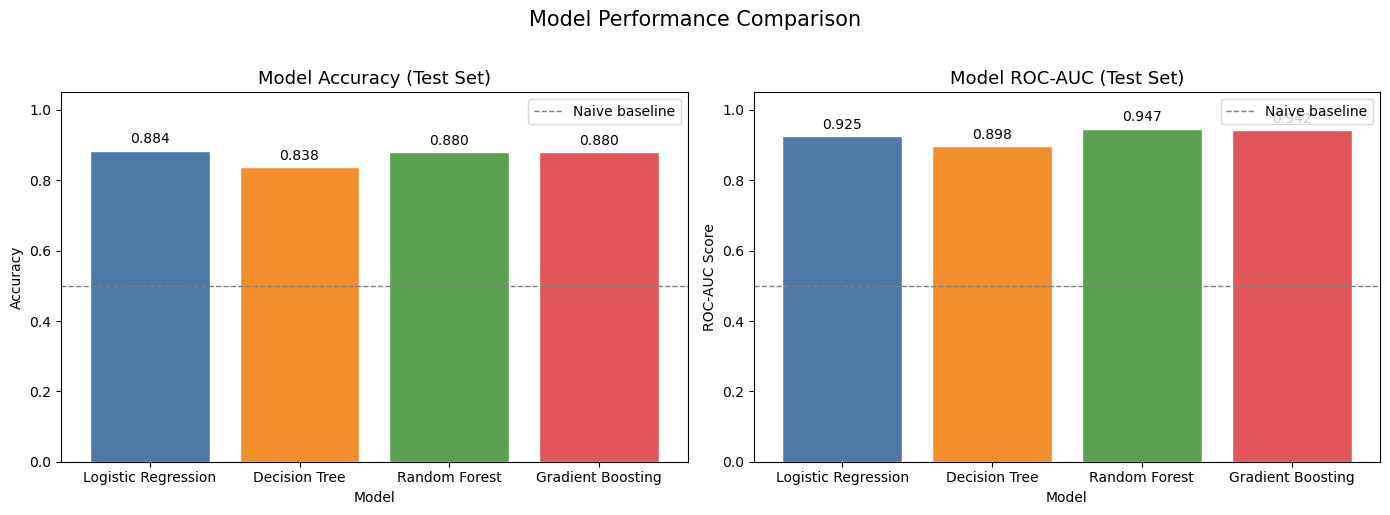

In [31]:
# bar chart comparison of accuracy and AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
accs = [lgr_acc, tree_acc, rf_acc, gb_acc]
aucs = [lgr_auc, tree_auc, rf_auc, gb_auc]
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

bars1 = axes[0].bar(models, accs, color=colors, edgecolor='white')
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=10)
axes[0].set_title('Model Accuracy (Test Set)', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel('Model')
axes[0].axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Naive baseline')
axes[0].legend()

bars2 = axes[1].bar(models, aucs, color=colors, edgecolor='white')
axes[1].bar_label(bars2, fmt='%.3f', padding=3, fontsize=10)
axes[1].set_title('Model ROC-AUC (Test Set)', fontsize=13)
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Model')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Naive baseline')
axes[1].legend()

plt.suptitle('Model Performance Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

##### Comparing Confusion Matrices

Confusion matrices show the breakdown of correct predictions (true positives and true negatives) and errors (false positives and false negatives). In this context, 0 = lost and 1 = won.

In [32]:
# compile predictions
lgr_preds  = lgr_grid.predict(X_test)
tree_preds = tree_grid.predict(X_test)
rf_preds   = rf_grid.predict(X_test)
gb_preds   = gb_grid.predict(X_test)

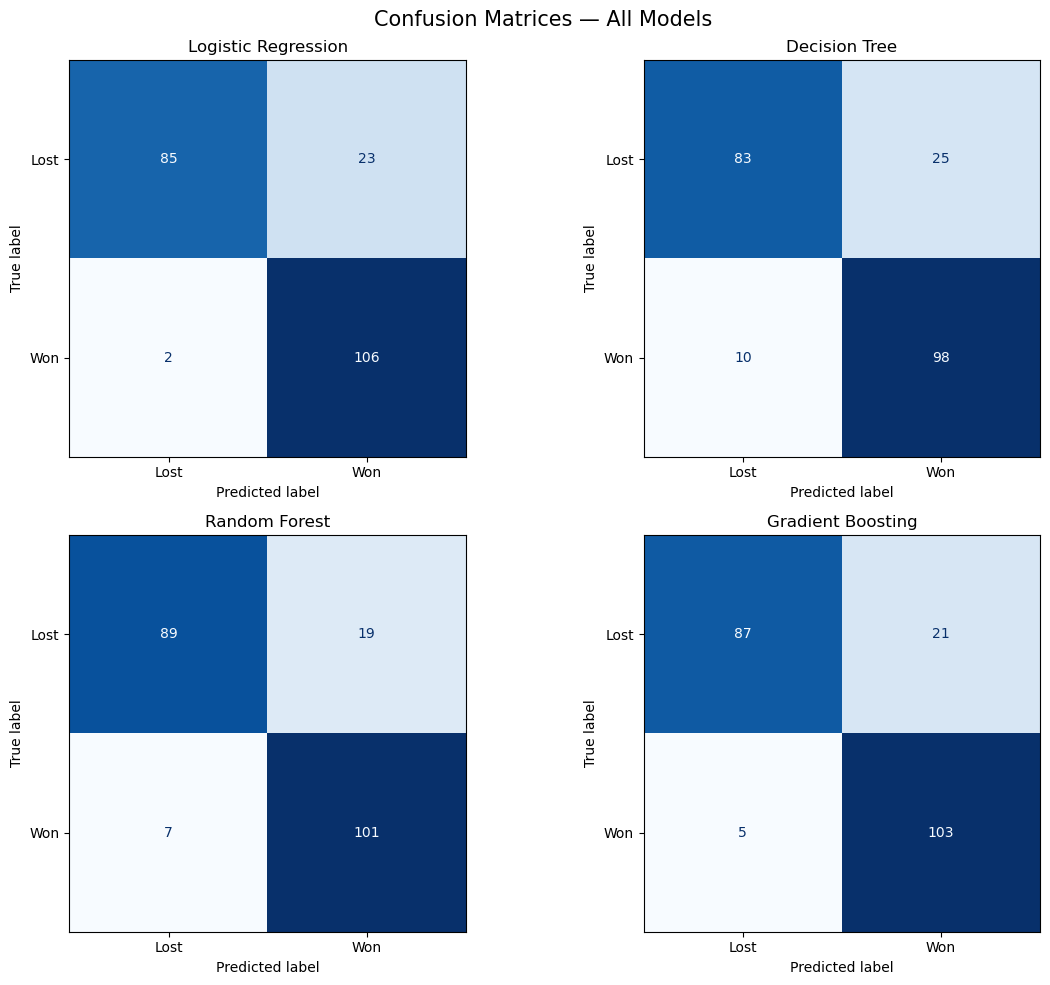

In [33]:
# 2x2 grid of confusion matrices — one per model
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, preds, title in zip(
    axes.flat,
    [lgr_preds, tree_preds, rf_preds, gb_preds],
    ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Lost', 'Won'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)
    ax.grid(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=15)
plt.tight_layout()
plt.show()

##### ROC Curves

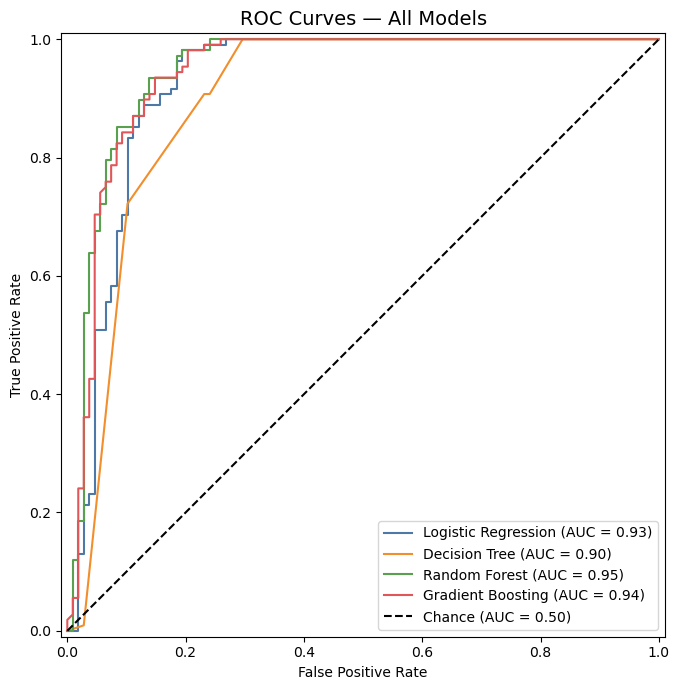

In [34]:
# overlay ROC curves for all four models on a single plot
fig, ax = plt.subplots(figsize=(8, 7))

for grid, label, color in [
    (lgr_grid,  'Logistic Regression', '#4e79a7'),
    (tree_grid, 'Decision Tree',        '#f28e2b'),
    (rf_grid,   'Random Forest',        '#59a14f'),
    (gb_grid,   'Gradient Boosting',    '#e15759')
]:
    RocCurveDisplay.from_estimator(grid, X_test, y_test, ax=ax,
                                   name=label, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
ax.set_title('ROC Curves — All Models', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### Selecting the Best Model

Based on the results above, **Gradient Boosting** achieves the highest ROC-AUC and accuracy of all four models, and is selected as the best model for this prediction task. Random Forest is a close second, confirming that ensemble methods outperform simpler approaches (logistic regression, decision tree) on this dataset.

We select the model with the highest ROC-AUC as our primary criterion because AUC is the most robust metric for binary classification — it measures the model's ability to rank candidates by win probability across all possible decision thresholds, regardless of the specific cutoff chosen.

This model will be re-fit with its optimal hyperparameters and evaluated in depth in Notebook 3, where we will examine feature importance, individual prediction examples, and model calibration.

In [35]:
# identify the best model by ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()
best_auc = results_df.loc[best_model_name, 'ROC-AUC']
best_acc = results_df.loc[best_model_name, 'Accuracy']

print(f'Best model: {best_model_name}')
print(f'ROC-AUC:    {best_auc:.4f}')
print(f'Accuracy:   {best_acc:.4f}')

Best model: Random Forest
ROC-AUC:    0.9470
Accuracy:   0.8796


In [36]:
# save test predictions for use in Notebook 3
# (using best model — update pipeline name below if needed)
best_grid = gb_grid  # update to lgr_grid / tree_grid / rf_grid if Gradient Boosting is not best

pred_df = X_test.copy()
pred_df['y_true'] = y_test.values
pred_df['y_pred'] = best_grid.predict(X_test)
pred_df['y_prob_win'] = best_grid.predict_proba(X_test)[:, 1]
pred_df.to_csv('data/test_predictions.csv', index=False)
print('Saved data/test_predictions.csv')

Saved data/test_predictions.csv
